# Neural Network from Scratch with NumPy

In this notebook we build a fully-connected neural network **from scratch** using only NumPy and train it on the classic MNIST handwritten-digit dataset.

### What you will learn
| Concept | Where |
|---------|-------|
| Weight initialisation (Xavier) | `NeuralNetwork.__init__` |
| Sigmoid activation & its derivative | `sigmoid`, `sigmoid_derivative` |
| Softmax for multi-class output | `softmax` |
| Cross-entropy loss | `cross_entropy_loss` |
| Forward pass | `forward` |
| Back-propagation (chain rule) | `backward` |
| Mini-batch stochastic gradient descent | `train` |

### Prerequisites
- Basic Python and NumPy
- Familiarity with matrix multiplication
- Basic calculus (partial derivatives)

---
## 0. Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

---
## 1. Dataset — MNIST (Yann LeCun)

MNIST contains **70,000 grayscale images** of handwritten digits (0–9), each of size 28×28 pixels (= 784 features).

We load it once here and visualise the first 10 samples.

Loading MNIST (this may take a moment the first time)...
Dataset shape  : (70000, 784)
Label range    : 0 – 9


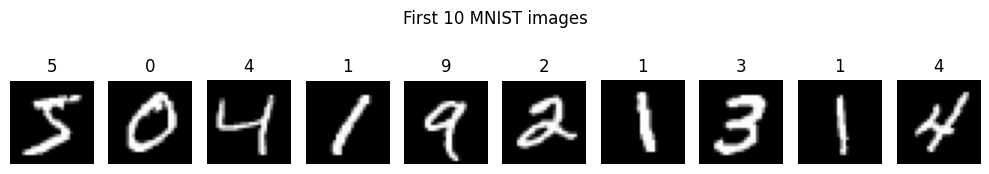

In [2]:
print("Loading MNIST (this may take a moment the first time)...")
mnist = fetch_openml('mnist_784', version=1, as_frame=False)

X_raw = mnist.data          # shape: (70000, 784)  – pixel values 0–255
y_raw = mnist.target.astype(int)  # shape: (70000,)    – digit labels 0–9

print(f"Dataset shape  : {X_raw.shape}")
print(f"Label range    : {y_raw.min()} – {y_raw.max()}")

# ── Visualise the first 10 samples ──────────────────────────────────────────
plt.figure(figsize=(10, 2))
for i in range(10):
    plt.subplot(1, 10, i + 1)
    plt.imshow(X_raw[i].reshape(28, 28), cmap="gray")
    plt.title(str(y_raw[i]))
    plt.axis("off")
plt.suptitle("First 10 MNIST images")
plt.tight_layout()
plt.show()

---
## 2. Pre-processing

Three steps before training:

1. **Normalise** pixel values from `[0, 255]` → `[0, 1]`.  
   Neural networks converge faster when inputs are small and centred.

2. **One-hot encode** the labels.  
   Instead of a single integer (e.g. `3`), each label becomes a vector of length 10  
   (e.g. `[0, 0, 0, 1, 0, 0, 0, 0, 0, 0]`). This is required by cross-entropy loss.

3. **Train / test split** — 80 % training, 20 % test.

In [3]:
# 1. Normalise
X = X_raw / 255.0

# 2. One-hot encode labels
encoder = OneHotEncoder(sparse_output=False)
y = encoder.fit_transform(y_raw.reshape(-1, 1))  # shape: (70000, 10)

# 3. Train / test split (stratified by default via random_state)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set   : {X_train.shape[0]} samples")
print(f"Test set       : {X_test.shape[0]} samples")
print(f"Input features : {X_train.shape[1]}  (28 × 28 pixels)")
print(f"Output classes : {y_train.shape[1]}")

Training set   : 56000 samples
Test set       : 14000 samples
Input features : 784  (28 × 28 pixels)
Output classes : 10


---
## 3. Neural Network — Theory Overview

### Architecture
```
Input (784)  →  Hidden 1 (sigmoid)  →  Hidden 2 (sigmoid)  →  Output (softmax, 10)
```

### Key equations

**Forward pass** (layer $l$):
$$z^{(l)} = A^{(l-1)} W^{(l)} + b^{(l)}, \qquad A^{(l)} = \sigma(z^{(l)})$$

**Sigmoid activation**:
$$\sigma(z) = \frac{1}{1+e^{-z}}, \qquad \sigma'(z) = \sigma(z)\,(1-\sigma(z))$$

**Softmax** (output layer, for class $k$):
$$\hat{y}_k = \frac{e^{z_k}}{\sum_j e^{z_j}}$$

**Cross-entropy loss**:
$$\mathcal{L} = -\frac{1}{m} \sum_{i=1}^{m} \sum_{k=1}^{K} y_{ik} \log(\hat{y}_{ik})$$

**Backpropagation** — output layer error (softmax + cross-entropy simplifies nicely):
$$\delta^{(L)} = \hat{y} - y$$

**Backpropagation** — hidden layer error:
$$\delta^{(l)} = (\delta^{(l+1)} W^{(l+1)\top}) \odot \sigma'(A^{(l)})$$

**Gradient descent update**:
$$W^{(l)} \leftarrow W^{(l)} - \eta \,\frac{1}{m}\, A^{(l-1)\top} \delta^{(l)}$$

---
## 4. NeuralNetwork Class

In [4]:
class NeuralNetwork:
    """
    Fully-connected feed-forward neural network trained with mini-batch SGD.

    Architecture
    ------------
    - Hidden layers : sigmoid activation
    - Output layer  : softmax activation  (multi-class classification)
    - Loss          : categorical cross-entropy

    Parameters
    ----------
    input_size    : number of input features (e.g. 784 for MNIST)
    hidden_layers : list of ints, number of units per hidden layer
                    e.g. [128, 64] creates two hidden layers
    output_size   : number of output classes (e.g. 10 for MNIST)
    learning_rate : step size for gradient descent (default 0.01)
    """

    def __init__(self, input_size, hidden_layers, output_size, learning_rate=0.01):
        self.learning_rate = learning_rate
        # Full layer size list: [input, hidden1, hidden2, ..., output]
        self.layers = [input_size] + hidden_layers + [output_size]
        self.weights = []
        self.biases = []
        self.loss_history = []

        print("Initialising network weights (Xavier initialisation):\n")
        total_params = 0

        for i in range(len(self.layers) - 1):
            n_in  = self.layers[i]
            n_out = self.layers[i + 1]

            # Xavier (Glorot) initialisation: keeps variance stable across layers.
            # Scaling by sqrt(1/n_in) prevents signals from exploding or vanishing
            # during the forward pass.
            w = np.random.randn(n_in, n_out) * np.sqrt(1.0 / n_in)
            b = np.zeros((1, n_out))  # biases start at zero

            self.weights.append(w)
            self.biases.append(b)

            num_params = n_in * n_out + n_out
            print(f"  Layer {i+1}: ({n_in} × {n_out})  |  Parameters: {num_params:,}")
            total_params += num_params

        print(f"\n  Total trainable parameters: {total_params:,}\n")

    # ── Activation functions ────────────────────────────────────────────────

    def sigmoid(self, z):
        """
        Sigmoid activation: σ(z) = 1 / (1 + e^{-z})

        Maps any real number to (0, 1). Used in hidden layers.
        """
        return 1.0 / (1.0 + np.exp(-z))

    def sigmoid_derivative(self, a):
        """
        Derivative of sigmoid *given its output* a = σ(z):
            σ'(z) = a * (1 - a)

        This elegant form avoids recomputing z during backprop —
        we only need the activation value that was cached during the forward pass.
        """
        return a * (1.0 - a)

    def softmax(self, z):
        """
        Softmax activation for the output layer.

        Converts raw scores (logits) to a probability distribution over classes.
        The max-subtraction trick (z - max(z)) prevents numerical overflow
        without changing the result, since e^{z-c} / Σe^{z-c} = e^z / Σe^z.
        """
        # Subtract per-sample max for numerical stability
        exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
        return exp_z / np.sum(exp_z, axis=1, keepdims=True)

    # ── Loss function ───────────────────────────────────────────────────────

    def cross_entropy_loss(self, y_pred, y_true):
        """
        Categorical cross-entropy loss (averaged over the batch):
            L = - (1/m) * Σ_i Σ_k  y_true[i,k] * log(y_pred[i,k])

        The small constant 1e-9 inside log prevents log(0) = -inf.

        Parameters
        ----------
        y_pred : (m, K)  predicted probabilities from softmax
        y_true : (m, K)  one-hot encoded ground-truth labels
        """
        m = y_true.shape[0]
        return -np.sum(y_true * np.log(y_pred + 1e-9)) / m

    # ── Forward pass ────────────────────────────────────────────────────────

    def forward(self, X):
        """
        Compute the forward pass through all layers.

        Returns
        -------
        activations : list of arrays, one per layer (including input).
                      activations[0]  = X (input)
                      activations[-1] = softmax output (predictions)
        """
        activations = [X]  # activations[0] is the input itself

        # Hidden layers: linear transform → sigmoid
        for w, b in zip(self.weights[:-1], self.biases[:-1]):
            z = np.dot(activations[-1], w) + b   # (m, n_in) · (n_in, n_out) → (m, n_out)
            a = self.sigmoid(z)
            activations.append(a)

        # Output layer: linear transform → softmax
        z_out = np.dot(activations[-1], self.weights[-1]) + self.biases[-1]
        a_out = self.softmax(z_out)
        activations.append(a_out)

        return activations

    # ── Backward pass (backpropagation) ─────────────────────────────────────

    def backward(self, y_true, activations):
        """
        Compute gradients of the loss w.r.t. every weight matrix and bias vector
        using the backpropagation algorithm.

        Core idea — chain rule applied layer by layer from output to input:
            δ^(L)   = ŷ − y                          (output error, softmax+CE simplifies)
            δ^(l)   = (δ^(l+1) · W^(l+1).T) ⊙ σ'(A^(l))   (hidden error)
            ∂L/∂W^(l) = A^(l-1).T · δ^(l)            (weight gradient)
            ∂L/∂b^(l) = sum of δ^(l) over samples     (bias gradient)

        Parameters
        ----------
        y_true      : (m, K)  one-hot labels
        activations : list returned by forward()

        Returns
        -------
        grads_w, grads_b : lists of gradient arrays, one per layer
        """
        grads_w = [None] * len(self.weights)
        grads_b = [None] * len(self.biases)

        # ── Output layer error ───────────────────────────────────────────────
        # For softmax + cross-entropy the gradient simplifies to (ŷ − y).
        # This is one of the most important results in neural network theory!
        delta = activations[-1] - y_true                  # (m, K)

        grads_w[-1] = np.dot(activations[-2].T, delta)    # (n_{L-1}, m) · (m, K)
        grads_b[-1] = np.sum(delta, axis=0, keepdims=True)

        # ── Propagate error backwards through hidden layers ──────────────────
        # Layer indices: len(self.layers)-2 down to 1  (skip input layer at 0)
        for l in range(len(self.layers) - 2, 0, -1):
            # Propagate delta through weights and apply sigmoid derivative
            delta = np.dot(delta, self.weights[l].T) * self.sigmoid_derivative(activations[l])

            grads_w[l - 1] = np.dot(activations[l - 1].T, delta)
            grads_b[l - 1] = np.sum(delta, axis=0, keepdims=True)

        return grads_w, grads_b

    # ── Parameter update ────────────────────────────────────────────────────

    def update_params(self, grads_w, grads_b, batch_size):
        """
        Apply one gradient descent step (averaged over the mini-batch).

        W ← W − η · (1/m) · ∂L/∂W

        Dividing by batch_size converts the summed gradients from backward()
        into the *mean* gradient — equivalent to averaging the loss over samples.
        """
        for i in range(len(self.weights)):
            self.weights[i] -= self.learning_rate * grads_w[i] / batch_size
            self.biases[i]  -= self.learning_rate * grads_b[i] / batch_size

    # ── Training loop ───────────────────────────────────────────────────────

    def train(self, X, y, epochs=100, batch_size=32):
        """
        Train the network with mini-batch stochastic gradient descent (SGD).

        Each epoch:
          1. Shuffle the training data (reduces variance between batches)
          2. Split into mini-batches of size `batch_size`
          3. For each mini-batch: forward → backward → update
          4. Compute and log the full-training-set loss

        Parameters
        ----------
        X          : (m, n)  training inputs
        y          : (m, K)  one-hot training labels
        epochs     : number of full passes over the training set
        batch_size : number of samples per gradient update
        """
        self.loss_history = []

        for epoch in range(epochs):
            # Shuffle data at the start of every epoch
            indices = np.arange(X.shape[0])
            np.random.shuffle(indices)
            X_shuffled = X[indices]
            y_shuffled = y[indices]

            # Mini-batch loop
            for start in range(0, X.shape[0], batch_size):
                X_batch = X_shuffled[start : start + batch_size]
                y_batch = y_shuffled[start : start + batch_size]

                activations          = self.forward(X_batch)
                grads_w, grads_b     = self.backward(y_batch, activations)
                self.update_params(grads_w, grads_b, X_batch.shape[0])

            # Compute training loss on the full dataset (for monitoring only)
            y_pred = self.forward(X)[-1]
            loss   = self.cross_entropy_loss(y_pred, y)
            self.loss_history.append(loss)

            print(f"Epoch {epoch+1:>3}/{epochs}  |  Loss: {loss:.4f}")

    # ── Inference ───────────────────────────────────────────────────────────

    def predict(self, X):
        """
        Return the predicted class index (argmax of softmax output) for each sample.

        Parameters
        ----------
        X : (m, n)  input array

        Returns
        -------
        (m,)  integer array of predicted class labels
        """
        probabilities = self.forward(X)[-1]  # (m, K)
        return np.argmax(probabilities, axis=1)

---
## 5. Training

We create a network with two hidden layers (128 and 64 units) and train it for 50 epochs.  
Feel free to experiment with different architectures and learning rates!

In [11]:
np.random.seed(42)  # reproducibility

nn = NeuralNetwork(
    input_size=784,
    hidden_layers=[64, 32],
    output_size=10,
    learning_rate=0.1
)

Initialising network weights (Xavier initialisation):

  Layer 1: (784 × 64)  |  Parameters: 50,240
  Layer 2: (64 × 32)  |  Parameters: 2,080
  Layer 3: (32 × 10)  |  Parameters: 330

  Total trainable parameters: 52,650



In [12]:
nn.train(X_train, y_train, epochs=50, batch_size=64)

Epoch   1/50  |  Loss: 0.8645
Epoch   2/50  |  Loss: 0.4609
Epoch   3/50  |  Loss: 0.3610
Epoch   4/50  |  Loss: 0.3164
Epoch   5/50  |  Loss: 0.2837
Epoch   6/50  |  Loss: 0.2600
Epoch   7/50  |  Loss: 0.2419
Epoch   8/50  |  Loss: 0.2224
Epoch   9/50  |  Loss: 0.2049
Epoch  10/50  |  Loss: 0.1920
Epoch  11/50  |  Loss: 0.1774
Epoch  12/50  |  Loss: 0.1665
Epoch  13/50  |  Loss: 0.1562
Epoch  14/50  |  Loss: 0.1488
Epoch  15/50  |  Loss: 0.1418
Epoch  16/50  |  Loss: 0.1352
Epoch  17/50  |  Loss: 0.1253
Epoch  18/50  |  Loss: 0.1198
Epoch  19/50  |  Loss: 0.1146
Epoch  20/50  |  Loss: 0.1088
Epoch  21/50  |  Loss: 0.1037
Epoch  22/50  |  Loss: 0.0995
Epoch  23/50  |  Loss: 0.0948
Epoch  24/50  |  Loss: 0.0910
Epoch  25/50  |  Loss: 0.0882
Epoch  26/50  |  Loss: 0.0843
Epoch  27/50  |  Loss: 0.0806
Epoch  28/50  |  Loss: 0.0781
Epoch  29/50  |  Loss: 0.0752
Epoch  30/50  |  Loss: 0.0722
Epoch  31/50  |  Loss: 0.0713
Epoch  32/50  |  Loss: 0.0670
Epoch  33/50  |  Loss: 0.0680
Epoch  34/

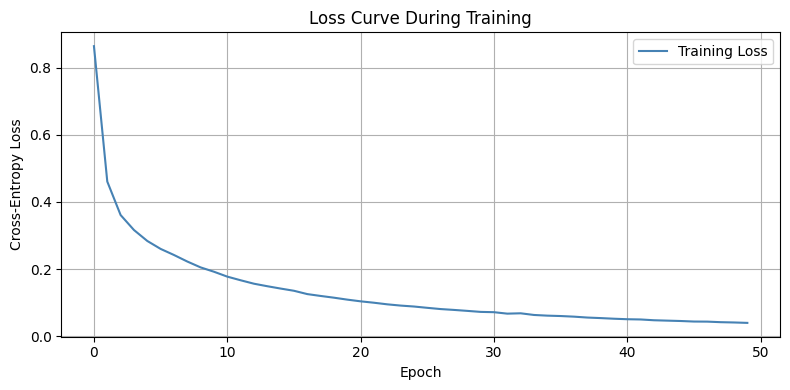

In [13]:
plt.figure(figsize=(8, 4))
plt.plot(nn.loss_history, label='Training Loss', color='steelblue')
plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.title("Loss Curve During Training")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

---
## 6. Evaluation

We evaluate the trained model on the **held-out test set** (data the network never saw during training).

> **sklearn convention**: all metric functions expect `(y_true, y_pred)` — true labels first, predictions second.

In [14]:
y_pred        = nn.predict(X_test)           # predicted class indices
y_test_labels = np.argmax(y_test, axis=1)    # convert one-hot → integer labels

accuracy = np.mean(y_pred == y_test_labels)
print(f"Test accuracy: {accuracy * 100:.2f}%")

Test accuracy: 97.00%


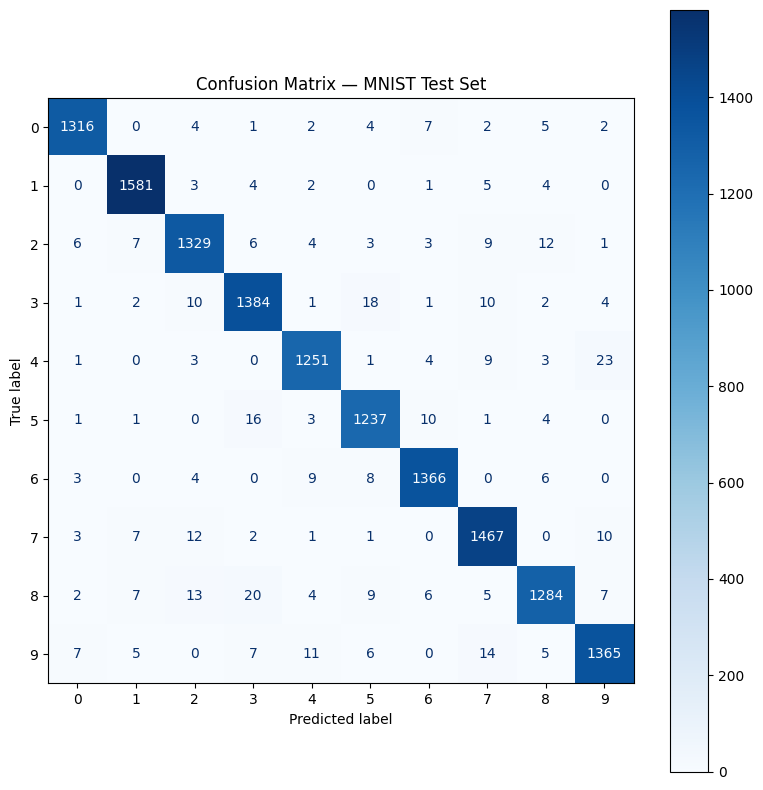

In [15]:
cm = confusion_matrix(y_test_labels, y_pred)   # (y_true, y_pred)

plt.figure(figsize=(8, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.arange(10))
disp.plot(cmap='Blues', values_format='d', ax=plt.gca())
plt.title("Confusion Matrix — MNIST Test Set")
plt.grid(False)
plt.tight_layout()
plt.show()

# Reading the matrix: row = true label, column = predicted label.
# Diagonal = correct predictions. Off-diagonal = mistakes.

In [16]:
# ── Per-class metrics ────────────────────────────────────────────────────────
# NOTE: sklearn signature is always (y_true, y_pred) — true labels come FIRST.

precision = precision_score(y_test_labels, y_pred, average=None)
recall    = recall_score(y_test_labels, y_pred, average=None)
f1        = f1_score(y_test_labels, y_pred, average=None)

print(f"{'Class':>6}  {'Precision':>10}  {'Recall':>8}  {'F1-score':>9}")
print("-" * 40)
for i in range(10):
    print(f"  {i:>4}   {precision[i]:.4f}      {recall[i]:.4f}    {f1[i]:.4f}")

print("\nFull classification report:")
print(classification_report(y_test_labels, y_pred))

 Class   Precision    Recall   F1-score
----------------------------------------
     0   0.9821      0.9799    0.9810
     1   0.9820      0.9881    0.9850
     2   0.9644      0.9630    0.9637
     3   0.9611      0.9658    0.9635
     4   0.9713      0.9660    0.9686
     5   0.9611      0.9717    0.9664
     6   0.9771      0.9785    0.9778
     7   0.9639      0.9760    0.9699
     8   0.9691      0.9462    0.9575
     9   0.9667      0.9613    0.9640

Full classification report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      1343
           1       0.98      0.99      0.99      1600
           2       0.96      0.96      0.96      1380
           3       0.96      0.97      0.96      1433
           4       0.97      0.97      0.97      1295
           5       0.96      0.97      0.97      1273
           6       0.98      0.98      0.98      1396
           7       0.96      0.98      0.97      1503
           8       0.97

---
## 7. Predicting a Custom Image

You can test the model on your own handwritten digit.  
Save a PNG/JPG image of a single digit and pass its path to `predict_image()`.

**Pre-processing applied automatically:**
- Convert to grayscale
- Resize to 28 × 28
- Invert colours if the background is white (MNIST uses white-on-black)
- Normalise to `[0, 1]`

In [ ]:
def predict_image(image_path, model):
    """
    Load a custom image, pre-process it to match MNIST format, and predict the digit.

    Parameters
    ----------
    image_path : str   path to a PNG or JPG image file
    model      : NeuralNetwork instance (already trained)
    """
    img      = Image.open(image_path).convert("L").resize((28, 28))
    img_arr  = np.array(img)

    # MNIST digits are white on black; invert if the image has a white background
    if np.mean(img_arr) > 127:
        img_arr = 255 - img_arr

    input_data = (img_arr / 255.0).reshape(1, -1)  # normalise and flatten
    prediction = model.predict(input_data)[0]

    plt.imshow(img_arr, cmap="gray")
    plt.title(f"Prediction: {prediction}", fontsize=14)
    plt.axis("off")
    plt.show()
    print(f"Predicted digit: {prediction}")


# Usage — replace the path with your own image:
# predict_image("images/example.png", nn)